# Data Processing Main Jupyter Notebook 

Data_processing_main.ipynb is acting as a main controller for running entire Bronze, Silver and Gold-layer data processing pipeline using PySpark. 

### Import Libraries 

In [1]:
### Core python libs 
import os
import glob
import random
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

### Data Science Tools 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### PySpark 
import pprint
import pyspark
import pyspark.sql.functions as F
from pyspark.sql import SparkSession, DataFrame
import pyspark.sql.functions as F
from pyspark.sql.functions import regexp_replace, col, when, regexp_extract, lower, lit, split, explode, array_contains, trim, to_date
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType, ArrayType
from pyspark.sql import functions as F
from pyspark.ml.feature import StringIndexer
from pyspark.sql.functions import udf

### Custom scripts from utils folder 
from utils.data_processing_bronze_table import process_bronze_table
import utils.data_processing_silver_table
import utils.data_processing_gold_table_v2

### Set Up PySpark Session

In [2]:
# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

25/06/16 03:23:59 WARN Utils: Your hostname, Xiao-Juns-Macbook-Pro-2.local resolves to a loopback address: 127.0.0.1; using 192.168.0.6 instead (on interface en0)
25/06/16 03:23:59 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/06/16 03:23:59 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


### Set Up Config
- Setting up configuration variables that define a snapshot date and a date range 
- Defines snapshot date for data, likely use this to filter records, or align features and labels temporally. 
- Defines start and end date for a date range to
    - Filter raw data to include only records within this date range
    - Define the timeframe for feature aggregation (e.g. "count no. of credit inquiries in past 12 months")
    - Ensure all features used in training come before or on the snapshot date (to prevent data leakage)
- Goal is to create a list like: ['2023-01-01', '2023-02-01', '2023-03-01', ..., '2024-12-01']
- This list represents the first day of each month from `start_date_str` ("2023-01-01") to `end_date_str` ("2024-12-01"). This is useful in time-based feature engineering or backtesting, where you:
    - Process or generate rolling features or time-specific gold tables for each monthly snapshot of your data
    - Want to loop over months to build your data incrementally
    - Backtest your ML pipeline at each time point

In [3]:
# set up config
snapshot_date_str = "2023-01-01"
start_date_str = "2023-01-01"
end_date_str = "2024-12-01"

In [4]:
# generate list of dates to process
def generate_first_of_month_dates(start_date_str, end_date_str):
    # Convert the date strings to datetime objects
    start_date = datetime.strptime(start_date_str, "%Y-%m-%d")
    end_date = datetime.strptime(end_date_str, "%Y-%m-%d")
    
    # List to store the first of month dates
    first_of_month_dates = []

    # Start from the first of the month of the start_date
    current_date = datetime(start_date.year, start_date.month, 1)

    while current_date <= end_date:
        # Append the date in yyyy-mm-dd format
        first_of_month_dates.append(current_date.strftime("%Y-%m-%d"))
        
        # Move to the first of the next month
        if current_date.month == 12:
            current_date = datetime(current_date.year + 1, 1, 1)
        else:
            current_date = datetime(current_date.year, current_date.month + 1, 1)

    return first_of_month_dates

dates_str_lst = generate_first_of_month_dates(start_date_str, end_date_str)
dates_str_lst

['2023-01-01',
 '2023-02-01',
 '2023-03-01',
 '2023-04-01',
 '2023-05-01',
 '2023-06-01',
 '2023-07-01',
 '2023-08-01',
 '2023-09-01',
 '2023-10-01',
 '2023-11-01',
 '2023-12-01',
 '2024-01-01',
 '2024-02-01',
 '2024-03-01',
 '2024-04-01',
 '2024-05-01',
 '2024-06-01',
 '2024-07-01',
 '2024-08-01',
 '2024-09-01',
 '2024-10-01',
 '2024-11-01',
 '2024-12-01']

### Build Bronze Table 
- In the Medallion Architecture, the Bronze layer's role is to:
    - Raw ingestion layer
    - Typically stores unchanged raw data (e.g. CSVs copied in full) as-is in the /bronze folder
    - Ensure all schemas are preserved

Here, we are automating Bronze layer of a medallion architecture data pipeline that: 
1. Takes raw CSV files (`lms_loan_daily.csv`, `feature_clickstream.csv`, `features_attributes.csv` & `features_financials.csv`) in the `data/` folder
2. Processes them for each month from Jan 2023 to Dec 2024 (over 2 years)
3. Outputs monthly processed CSVs to individual folders within `datamart/bronze/`

Essentially building a Bronze layer "time-sliced" data lake using raw input files.

Resulting output: ~ 24 * 4 = 96 monthly bronze CSV files inside `datamart/bronze/`

Each file is an unprocessed or lightly processed time-filtered extract of the full dataset


In [5]:
# Base path for all bronze tables
bronze_base_dir = "datamart/bronze/"

# Create the base directory if it doesn't exist
if not os.path.exists(bronze_base_dir):
    os.makedirs(bronze_base_dir)

In [6]:
# run bronze backfill
for date_str in dates_str_lst:
    utils.data_processing_bronze_table.process_bronze_table(date_str, bronze_base_dir, spark)

lms (2023-01-01) row count: 530
Saved lms to: datamart/bronze/lms/bronze_lms_2023_01_01.csv
financials (2023-01-01) row count: 530
Saved financials to: datamart/bronze/financials/bronze_financials_2023_01_01.csv
attributes (2023-01-01) row count: 530
Saved attributes to: datamart/bronze/attributes/bronze_attributes_2023_01_01.csv
clickstream (2023-01-01) row count: 8974


Saved clickstream to: datamart/bronze/clickstream/bronze_clickstream_2023_01_01.csv
lms (2023-02-01) row count: 1031
Saved lms to: datamart/bronze/lms/bronze_lms_2023_02_01.csv
financials (2023-02-01) row count: 501
Saved financials to: datamart/bronze/financials/bronze_financials_2023_02_01.csv
attributes (2023-02-01) row count: 501
Saved attributes to: datamart/bronze/attributes/bronze_attributes_2023_02_01.csv
clickstream (2023-02-01) row count: 8974
Saved clickstream to: datamart/bronze/clickstream/bronze_clickstream_2023_02_01.csv
lms (2023-03-01) row count: 1537
Saved lms to: datamart/bronze/lms/bronze_lms_2023_03_01.csv
financials (2023-03-01) row count: 506
Saved financials to: datamart/bronze/financials/bronze_financials_2023_03_01.csv
attributes (2023-03-01) row count: 506
Saved attributes to: datamart/bronze/attributes/bronze_attributes_2023_03_01.csv
clickstream (2023-03-01) row count: 8974
Saved clickstream to: datamart/bronze/clickstream/bronze_clickstream_2023_03_01.csv


In [6]:
# inspect output of the CSV file created in the bronze datamart 

pd.read_csv("datamart/bronze/lms/bronze_lms_2024_12_01.csv").head()


,loan_id,Customer_ID,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date
0,CUS_0x100b_2024_03_01,CUS_0x100b,2024-03-01,10,9,10000,1000.0,1000.0,0.0,1000.0,2024-12-01
1,CUS_0x102e_2024_04_01,CUS_0x102e,2024-04-01,10,8,10000,1000.0,0.0,6000.0,8000.0,2024-12-01
2,CUS_0x1038_2024_10_01,CUS_0x1038,2024-10-01,10,2,10000,1000.0,1000.0,0.0,8000.0,2024-12-01
3,CUS_0x103e_2024_12_01,CUS_0x103e,2024-12-01,10,0,10000,0.0,0.0,0.0,10000.0,2024-12-01
4,CUS_0x1048_2024_02_01,CUS_0x1048,2024-02-01,10,10,10000,1000.0,0.0,9000.0,9000.0,2024-12-01


### Build Silver Table
In the Medallion Architecture, the Silver layer is the refined, cleaned, and joined data layer. It builds on the raw Bronze data by applying transformations that make the data analytics-ready. Specifically:
- Transforms raw ingested data (from Bronze) into a clean, structured, and enriched format
- Validates schema, removes nulls, casts datatypes, and standardizes values
- Joins multiple datasets to form unified views or denormalized tables
- Enables easier downstream consumption by analytics or business teams

Here, we are automating Silver layer of a medallion architecture data pipeline that: 
1. Reads time-partitioned monthly Bronze CSVs (produced earlier) for the same `snapshot_date` 
2. Clean each datasets by
    - Removing duplicate rows
    - Handling missing/null values (e.g. drop now or impute in gold layer)
    - Standardize data formats (e.g. convert types, format dates)
3. Apply domain rules:
   - Filter only approved loans
   - Clean up outliers
   - Normalize values 
4. Join tables on a common key (e.g. Customer_ID) - likely to perform a series of left joins
5. Store the joined, cleaned result to:
   - `datamart/silver/merged`
   - One monthly merged Silver CSV file per snapshot (~ 24 CSV files)


In [7]:
# create silver datalake
silver_base_dir = "datamart/silver/"

if not os.path.exists(silver_base_dir):
    os.makedirs(silver_base_dir)

In [8]:
# run silver backfill
for date_str in dates_str_lst:
    utils.data_processing_silver_table.process_silver_loan_table(date_str, bronze_base_dir, silver_base_dir, spark)
    utils.data_processing_silver_table.process_silver_attributes_table(date_str, bronze_base_dir, silver_base_dir, spark)
    utils.data_processing_silver_table.process_silver_financials_table(date_str, bronze_base_dir, silver_base_dir, spark)
    utils.data_processing_silver_table.process_silver_clickstream_table(date_str, bronze_base_dir, silver_base_dir, spark)


loaded bronze table from:  datamart/bronze/lms/bronze_lms_2023_01_01.csv row count:  530


saved silver table to:  datamart/silver/lms/silver_lms_2023_01_01.parquet row count:  530
loaded from: datamart/bronze/attributes/bronze_attributes_2023_01_01.csv row count: 530
saved silver table to: datamart/silver/attributes/silver_attributes_2023_01_01.parquet row count: 530
loaded from: datamart/bronze/financials/bronze_financials_2023_01_01.csv row count: 530


saved silver table to: datamart/silver/financials/silver_financials_2023_01_01.parquet row count: 530
loaded from: datamart/bronze/clickstream/bronze_clickstream_2023_01_01.csv row count: 8974
saved silver table to: datamart/silver/clickstream/silver_clickstream_2023_01_01.parquet row count: 8974
loaded bronze table from:  datamart/bronze/lms/bronze_lms_2023_02_01.csv row count:  1031
saved silver table to:  datamart/silver/lms/silver_lms_2023_02_01.parquet row count:  1031
loaded from: datamart/bronze/attributes/bronze_attributes_2023_02_01.csv row count: 501
saved silver table to: datamart/silver/attributes/silver_attributes_2023_02_01.parquet row count: 501
loaded from: datamart/bronze/financials/bronze_financials_2023_02_01.csv row count: 501
saved silver table to: datamart/silver/financials/silver_financials_2023_02_01.parquet row count: 501
loaded from: datamart/bronze/clickstream/bronze_clickstream_2023_02_01.csv row count: 8974
saved silver table to: datamart/silver/clickstream

In [9]:
# Ensure all columns are shown
pd.set_option("display.max_columns", None)

# Inspect the silver loan table
utils.data_processing_silver_table.process_silver_loan_table(date_str, bronze_base_dir, silver_base_dir, spark).toPandas()

loaded bronze table from:  datamart/bronze/lms/bronze_lms_2024_12_01.csv row count:  5531
saved silver table to:  datamart/silver/lms/silver_lms_2024_12_01.parquet row count:  5531


,loan_id,Customer_ID,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date,mob,installments_missed,first_missed_date,dpd
0,CUS_0x100b_2024_03_01,CUS_0x100b,2024-03-01,10,9,10000.0,1000.0,1000.0,0.0,1000.0,2024-12-01,9,0,None,0
1,CUS_0x102e_2024_04_01,CUS_0x102e,2024-04-01,10,8,10000.0,1000.0,0.0,6000.0,8000.0,2024-12-01,8,6,2024-06-01,183
2,CUS_0x1038_2024_10_01,CUS_0x1038,2024-10-01,10,2,10000.0,1000.0,1000.0,0.0,8000.0,2024-12-01,2,0,None,0
3,CUS_0x103e_2024_12_01,CUS_0x103e,2024-12-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2024-12-01,0,0,None,0
4,CUS_0x1048_2024_02_01,CUS_0x1048,2024-02-01,10,10,10000.0,1000.0,0.0,9000.0,9000.0,2024-12-01,10,9,2024-03-01,275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5526,CUS_0xfe3_2024_04_01,CUS_0xfe3,2024-04-01,10,8,10000.0,1000.0,1000.0,0.0,2000.0,2024-12-01,8,0,None,0
5527,CUS_0xff3_2024_06_01,CUS_0xff3,2024-06-01,10,6,10000.0,1000.0,1000.0,0.0,4000.0,2024-12-01,6,0,None,0
5528,CUS_0xff4_2024_12_01,CUS_0xff4,2024-12-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2024-12-01,0,0,None,0
5529,CUS_0xff6_2024_10_01,CUS_0xff6,2024-10-01,10,2,10000.0,1000.0,1000.0,0.0,8000.0,2024-12-01,2,0,None,0


In [10]:
# Ensure all columns are shown
pd.set_option("display.max_columns", None)

# Inspect the silver attributes table
df = utils.data_processing_silver_table.process_silver_attributes_table(date_str, bronze_base_dir, silver_base_dir, spark).toPandas()

df

loaded from: datamart/bronze/attributes/bronze_attributes_2024_12_01.csv row count: 515
saved silver table to: datamart/silver/attributes/silver_attributes_2024_12_01.parquet row count: 515


,Customer_ID,Name,SSN,snapshot_date,Age,occupation_developer,occupation_scientist,occupation_engineer,occupation_teacher,occupation_manager,occupation_enterpreneur,occupation_mechanic,occupation_musician,occupation_architect,occupation_writer,occupation_accountant,occupation_journalist,occupation_lawyer,occupation_doctor,occupation_media_manager,occupation_unknown
0,CUS_0x103e,Tim Kellyf,155-72-8070,2024-12-01,40.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,CUS_0x1195,Alexk,822-48-3629,2024-12-01,31.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2,CUS_0x1197,Nayako,799-23-8283,2024-12-01,28.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,CUS_0x11e2,Valetkevitchr,809-04-1419,2024-12-01,34.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
4,CUS_0x11ec,William Schombergh,417-74-2163,2024-12-01,34.0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510,CUS_0xe6c,Doris Frankelh,172-24-1577,2024-12-01,26.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
511,CUS_0xe99,Moone,164-90-3178,2024-12-01,48.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
512,CUS_0xf55,Tarmo Virkip,025-54-8593,2024-12-01,39.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
513,CUS_0xfd1,Frewy,389-55-6408,2024-12-01,32.0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0


In [19]:
# Ensure all columns are shown
pd.set_option("display.max_columns", None)

# Inspect the silver financials table
utils.data_processing_silver_table.process_silver_financials_table(date_str, bronze_base_dir, silver_base_dir, spark).toPandas()

loaded from: datamart/bronze/financials/bronze_financials_2024_12_01.csv row count: 515
saved silver table to: datamart/silver/financials/silver_financials_2024_12_01.parquet row count: 515


,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,snapshot_date,Num_of_Delayed_Payment,Credit_Mix_None,Credit_Mix_Good,Credit_Mix_Standard,Payment_of_Min_Amount_Yes,Payment_of_Min_Amount_No,Payment_of_Min_Amount_NM,Payment_of_Min_Amount_None,Credit_History_Months,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments,Payment_Behaviour_None,Loan_Not_Specified,Loan_debt_consolidation_loan,Loan_personal_loan,Loan_payday_loan,Loan_mortgage_loan,Loan_credit_builder_loan,Loan_auto_loan,Loan_home_equity_loan,Loan_student_loan
0,CUS_0x103e,98690.796875,8262.233398,4.0,6.0,9.0,1.0,6,10.760000,4.0,706.960022,26.860664,55.004406,913.481323,147.737610,2024-12-01,17.0,0,1,0,0,1,0,0,323,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1
1,CUS_0x1195,30429.910156,2808.825928,4.0,6.0,16.0,2.0,22,1.670000,NaN,362.480011,33.349049,29.914076,82.878784,438.089722,2024-12-01,17.0,0,0,1,0,1,0,0,347,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0
2,CUS_0x1197,92300.007812,7437.667480,2.0,4.0,11.0,3.0,27,18.959999,2.0,755.169983,26.989786,1000.000000,220.862152,581.156799,2024-12-01,9.0,1,0,0,1,0,0,0,227,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0
3,CUS_0x11e2,44986.550781,3689.879150,6.0,5.0,11.0,1.0,0,10.260000,3.0,753.210022,25.586287,23.267136,43.203632,542.517151,2024-12-01,4.0,0,1,0,0,1,0,0,240,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
4,CUS_0x11ec,14867.690430,1005.974182,9.0,9.0,18.0,6.0,39,18.500000,8.0,2344.060059,24.344387,55.459602,100.145752,224.992065,2024-12-01,15.0,0,0,1,1,0,0,0,206,0,0,0,0,1,0,0,0,1,1,0,0,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510,CUS_0xe6c,125597.523438,9367.500000,1.0,3.0,12.0,4.0,2,9.890000,4.0,1294.939941,30.324257,1000.000000,964.538086,763.398193,2024-12-01,9.0,0,1,0,0,0,1,0,365,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,1
511,CUS_0xe99,45461.539062,3917.461670,6.0,3.0,5.0,2.0,20,11.380000,6.0,647.239990,27.264685,69.318352,42.941002,519.486816,2024-12-01,9.0,0,0,1,0,1,0,0,201,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0
512,CUS_0xf55,78443.476562,6358.956543,7.0,5.0,23.0,4.0,39,6.370000,6.0,1527.770020,24.704428,177.387558,528.746887,209.761200,2024-12-01,19.0,0,0,0,0,0,1,0,190,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,1
513,CUS_0xfd1,78666.570312,6485.547363,3.0,4.0,17.0,4.0,29,5.370000,3.0,1498.699951,37.831760,247.851151,252.346130,408.357483,2024-12-01,10.0,0,0,1,0,1,0,0,269,0,0,1,0,0,0,0,1,1,1,0,0,0,0,1,0


In [20]:
# Ensure all columns are shown
pd.set_option("display.max_columns", None)

# Inspect the silver clickstream table
utils.data_processing_silver_table.process_silver_clickstream_table(date_str, bronze_base_dir, silver_base_dir, spark).toPandas()

loaded from: datamart/bronze/clickstream/bronze_clickstream_2024_12_01.csv row count: 8974
saved silver table to: datamart/silver/clickstream/silver_clickstream_2024_12_01.parquet row count: 8974


,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,fe_11,fe_12,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,Customer_ID,snapshot_date
0,145,189,109,134,196,-37,101,82,111,24,-26,-17,65,249,200,185,-83,-18,-76,30,CUS_0x1037,2024-12-01
1,40,184,187,75,192,146,38,109,353,141,-9,-22,-14,193,125,117,215,91,33,255,CUS_0x1069,2024-12-01
2,98,121,180,200,95,48,59,194,76,84,298,-57,167,101,92,185,98,68,-60,116,CUS_0x114a,2024-12-01
3,85,96,19,47,30,39,-32,210,-81,206,37,105,143,94,139,237,78,187,77,33,CUS_0x1184,2024-12-01
4,98,45,155,56,112,47,52,138,153,225,31,40,-43,142,121,10,189,110,264,241,CUS_0x1297,2024-12-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8969,414,22,72,57,142,192,11,139,24,63,43,191,179,91,20,189,-35,-19,15,66,CUS_0xdf6,2024-12-01
8970,116,-124,-108,212,-21,227,146,112,186,-65,292,35,38,226,319,98,9,152,17,14,CUS_0xe23,2024-12-01
8971,237,-3,-49,375,144,41,-170,324,19,266,275,80,7,102,64,191,124,220,231,75,CUS_0xe4e,2024-12-01
8972,5,67,211,83,207,-41,325,14,-18,41,133,61,109,266,28,157,131,116,101,131,CUS_0xedd,2024-12-01


### EDA on Credit Labels
- Performing EDA on silver table to understand the rs between loan age (mob) and loan delinquency (measured as dpd flag)

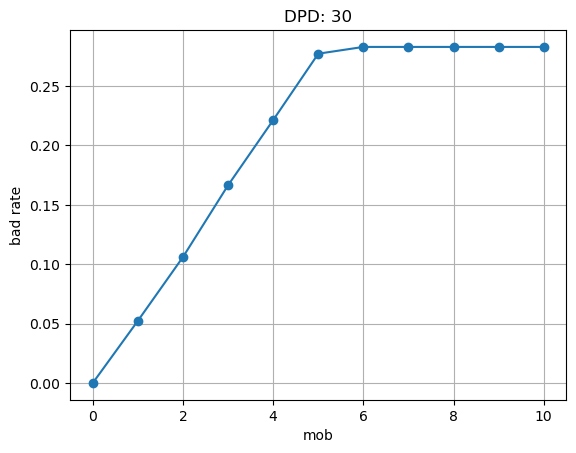

In [11]:
# set dpd label definition
### defines the threshold for what counts as a "bad" (delinquent) loan - 30 days past due 
dpd = 30

# Define folder path as a string, ensure trailing slash or handle in os.path.join
silver_lms_directory = "datamart/silver/lms"

# List all parquet files in the folder (assuming files have .parquet extension)
files_list = glob.glob(os.path.join(silver_lms_directory, '*.parquet'))

# Read all parquet files into a single DataFrame
df = spark.read.option("header", "true").parquet(*files_list)

# filter only completed loans
### Keep loans that started before 2024, these are likely to have at least 10 installments, more complete history 
df = df.filter(col("loan_start_date") < datetime.strptime("2024-01-01", "%Y-%m-%d"))

# create dpd flag if more than dpd
### adds a binary columns: 1 if DPD is 30 or more, 0 otherwise 
### this is your label for loan performance (good vs bad)
df = df.withColumn("dpd_flag", F.when(col("dpd") >= dpd, 1).otherwise(0))

# actual bads 
### selects records at the 10th installment 
### these could be used to evaluate "bad loan" performance at maturity or to define ground truth for model training/ validation later
actual_bads_df = df.filter(col("installment_num") == 10)

# prepare for analysis
### focus only on loans before maturity 
### useful if you're doing early-stage risk prediction 
# df = df.filter(col("installment_num") < 10)

# visualise bad rate
### converts Spark DF into pandas DF to allow matplotlib plotting 
pdf = df.toPandas()

# Group by col_A and count occurrences in col_B
### groups by mob (months on book)
### for each mob, computes the mean of dpd_flag i.e. bad rate 
grouped = pdf.groupby('mob')['dpd_flag'].mean()

# Sort the index (x-axis) of the grouped DataFrame
grouped = grouped.sort_index()

### Plotting line chart to show how delinquency rate changes with mob 
### Helps visualize whether default likelihood increases or decreases as the loan matures
### The trend in the plot shows loan risk progression across time, peaks may suggest when customers are most likely to default 
### (at month 4 or 5). Insightful for credit risk modeling, early warning systems, loan product design 
grouped.plot(kind='line', marker='o')

plt.title('DPD: '+ str(dpd))
plt.xlabel('mob')
plt.ylabel('bad rate')
plt.grid(True)
plt.show()


In [12]:
df.show()

+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+---+-------------------+-----------------+---+--------+
|             loan_id|Customer_ID|loan_start_date|tenure|installment_num|loan_amt|due_amt|paid_amt|overdue_amt|balance|snapshot_date|mob|installments_missed|first_missed_date|dpd|dpd_flag|
+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+---+-------------------+-----------------+---+--------+
|CUS_0x1011_2023_1...| CUS_0x1011|     2023-11-01|    10|             10| 10000.0| 1000.0|  1000.0|        0.0|    0.0|   2024-09-01| 10|                  0|             NULL|  0|       0|
|CUS_0x1013_2023_1...| CUS_0x1013|     2023-12-01|    10|              9| 10000.0| 1000.0|  1000.0|        0.0| 1000.0|   2024-09-01|  9|                  0|             NULL|  0|       0|
|CUS_0x1018_2023_1...| CUS_0x1018|     2023-11-01|    1

### Build Gold Table
Gold Table / Gold Layer is the final, highly curated, business-level data layer built on top of the Silver layer. It is analytics- and ML-ready, often serving as a feature store and label store for model training, evaluation, and production. Key characteristics:
- Aggregated and enriched: Combines multiple Silver tables into comprehensive datasets, often with aggregations, feature engineering, and domain-specific calculations.
- Clean, validated, and consistent: Data quality is highest here, with strict enforcement of schema, value constraints, and completeness.
- Optimized for consumption: Structured for efficient querying, reporting, and feeding machine learning pipelines (batch or real-time).
- Supports ML lifecycle: Stores features and labels separately but linked, enabling easy retrieval and management of datasets for supervised learning.
- May include historical snapshots: To support time-series models and model drift monitoring.
- Business logic embedded: Domain-specific KPIs, risk scores, customer segments, or other derived metrics live here.


In [8]:
# create gold datalake
gold_base_dir = "datamart/gold/"

if not os.path.exists(gold_base_dir):
    os.makedirs(gold_base_dir)

In [ ]:
# run gold backfill
utils.data_processing_gold_table_v2.process_gold_feature_and_label_store(silver_base_dir, gold_base_dir, spark, dpd_cutoff = 30, mob_cutoff = 6)


=== Loading Data Sources ===


Loaded attributes_df: 11974 rows, 21 columns


Unique customers in attributes: 11974
Loaded clickstream_df: 215376 rows, 22 columns
Unique customers in clickstream: 8974
Loaded lms_df: 104288 rows, 15 columns
Unique customers in LMS: 11974
Loaded financials_df: 11974 rows, 41 columns
Unique customers in financials: 11974

=== Finding Valid Snapshot Dates ===

=== Processing Feature and Label Stores ===

=== Creating Final Stores ===


Feature Store: 8974 rows
📌 Building label store…
✅ Label store created


Combined Store: 8974 rows

=== Saving Data Stores ===


...

Unique customers in LMS: 11974


Loaded financials_df: 11974 rows, 41 columns


Unique customers in financials: 11974

=== Finding Valid Snapshot Dates ===

=== Processing Feature and Label Stores ===

=== Creating Final Stores ===


ERROR:root:KeyboardInterrupt while sending command.          (1540 + 10) / 3600]
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/py4j/clientserver.py", line 511, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/socket.py", line 707, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt


KeyboardInterrupt: 

In [11]:
filepath = "datamart/gold/label_store"
gold_label_df = pd.read_parquet(filepath)
pd.set_option('display.max_columns', None)
gold_label_df.head() 


,Customer_ID,loan_id,label,snapshot_date,label_def
0,CUS_0x100b,CUS_0x100b_2024_03_01,0,2024-09-01,30dpd_6mob
1,CUS_0x1096,CUS_0x1096_2024_03_01,1,2024-09-01,30dpd_6mob
2,CUS_0x111c,CUS_0x111c_2024_03_01,1,2024-09-01,30dpd_6mob
3,CUS_0x112d,CUS_0x112d_2024_03_01,1,2024-09-01,30dpd_6mob
4,CUS_0x1204,CUS_0x1204_2024_03_01,1,2024-09-01,30dpd_6mob


In [19]:
# Show column names
print("Columns:", gold_label_df.columns)

# Get number of rows
num_rows = gold_label_df.count()
print("Number of rows:", num_rows)

# Get number of columns
num_cols = len(gold_label_df.columns)
print("Number of columns:", num_cols)

# Shape of the DataFrame
print("Shape: (rows, columns) =", (num_rows, num_cols))

Columns: Index(['Customer_ID', 'loan_id', 'label', 'snapshot_date', 'label_def'], dtype='object')
Number of rows: Customer_ID      8974
loan_id          8974
label            8974
snapshot_date    8974
label_def        8974
dtype: int64
Number of columns: 5
Shape: (rows, columns) = (Customer_ID      8974
loan_id          8974
label            8974
snapshot_date    8974
label_def        8974
dtype: int64, 5)


In [12]:
filepath = "datamart/gold/feature_store"
gold_feature_df = pd.read_parquet(filepath)

pd.set_option('display.max_columns', None)
gold_feature_df.head() 


,Customer_ID,Name,SSN,snapshot_date,Age,occupation_developer,occupation_scientist,occupation_engineer,occupation_teacher,occupation_manager,occupation_enterpreneur,occupation_mechanic,occupation_musician,occupation_architect,occupation_writer,occupation_accountant,occupation_journalist,occupation_lawyer,occupation_doctor,occupation_media_manager,occupation_unknown,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Num_of_Delayed_Payment,Credit_Mix_None,Credit_Mix_Good,Credit_Mix_Standard,Payment_of_Min_Amount_Yes,Payment_of_Min_Amount_No,Payment_of_Min_Amount_NM,Payment_of_Min_Amount_None,Credit_History_Months,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments,Payment_Behaviour_None,Loan_Not_Specified,Loan_debt_consolidation_loan,Loan_personal_loan,Loan_payday_loan,Loan_mortgage_loan,Loan_credit_builder_loan,Loan_auto_loan,Loan_home_equity_loan,Loan_student_loan,disposable_income,DTI,num_active_loans,credit_history_bucket_Short,credit_history_bucket_Medium,credit_history_bucket_Long,credit_history_bucket_None,credit_inquiries_bucket_Low,credit_inquiries_bucket_Medium,credit_inquiries_bucket_High,credit_inquiries_bucket_None,avg_fe_1,avg_fe_2,avg_fe_3,avg_fe_4,avg_fe_5,avg_fe_6,avg_fe_7,avg_fe_8,avg_fe_9,avg_fe_10,avg_fe_11,avg_fe_12,avg_fe_13,avg_fe_14,avg_fe_15,avg_fe_16,avg_fe_17,avg_fe_18,avg_fe_19,avg_fe_20,feature_snapshot_date
0,CUS_0x1b66,Valetkevitchj,444-26-5685,2023-01-01,34.0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,50538.578125,4054.548340,6.0,7.0,9.0,4.0,17,9.09,6.0,1205.130005,23.560961,164.807465,256.246460,254.400909,21.0,0,0,1,0,0,1,0,108,0,0,0,1,0,0,0,0,1,0,1,1,0,1,0,0,3889.740967,0.040648,4,0,0,1,0,0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-01-01
1,CUS_0x2abc,Karenf,102-67-0486,2023-01-01,19.0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,13864.834961,949.402893,3.0,3.0,9.0,1.0,10,14.65,1.0,554.130005,31.098274,10.420393,59.225185,295.294708,14.0,0,0,1,1,0,0,0,360,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,938.982483,0.010976,1,0,0,1,0,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-01-01
2,CUS_0x75e,Koltrowitzq,606-90-0153,2023-01-01,38.0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,77190.523438,6470.543457,4.0,7.0,5.0,7.0,13,12.30,7.0,75.940002,26.465611,253.049164,NaN,587.592529,12.0,0,0,1,1,0,0,0,202,1,0,0,0,0,0,0,1,1,1,0,0,0,1,1,0,6217.494141,0.039108,4,0,0,1,0,0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-01-01
3,CUS_0x7910,Raymondu,995-60-4305,2023-01-01,35.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,118645.796875,9525.400391,2.0,5.0,5.0,3.0,2,5.56,4.0,1480.890015,35.547718,861.917175,202.605072,840.542358,10.0,0,1,0,0,1,0,0,351,1,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,8663.483398,0.090486,3,0,0,1,0,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-01-01
4,CUS_0x79ac,Jean-Baptistea,833-71-1983,2023-01-01,40.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,46645.859375,4056.155029,4.0,3.0,5.0,2.0,10,10.89,9.0,1157.310059,36.326778,61.795319,392.293030,241.527161,10.0,0,0,1,1,0,0,0,137,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,3994.359619,0.015235,1,0,0,1,0,0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-01-01


In [16]:
# Show column names
print("Columns:", gold_feature_df.columns)

# Get number of rows
num_rows = gold_feature_df.count()
print("Number of rows:", num_rows)

# Get number of columns
num_cols = len(gold_feature_df.columns)
print("Number of columns:", num_cols)

# Shape of the DataFrame
print("Shape: (rows, columns) =", (num_rows, num_cols))

Columns: Index(['Customer_ID', 'Name', 'SSN', 'snapshot_date', 'Age',
       'occupation_developer', 'occupation_scientist', 'occupation_engineer',
       'occupation_teacher', 'occupation_manager', 'occupation_enterpreneur',
       'occupation_mechanic', 'occupation_musician', 'occupation_architect',
       'occupation_writer', 'occupation_accountant', 'occupation_journalist',
       'occupation_lawyer', 'occupation_doctor', 'occupation_media_manager',
       'occupation_unknown', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Changed_Credit_Limit', 'Num_Credit_Inquiries',
       'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Monthly_Balance', 'Num_of_Delayed_Payment',
       'Credit_Mix_None', 'Credit_Mix_Good', 'Credit_Mix_Standard',
       'Payment_of_Min_Amount_Yes', 'Payment_of_Min_Amount_No',
       'Payment_of_Min_Am

In [18]:
gold_feature_df.describe()


,Age,occupation_developer,occupation_scientist,occupation_engineer,occupation_teacher,occupation_manager,occupation_enterpreneur,occupation_mechanic,occupation_musician,occupation_architect,occupation_writer,occupation_accountant,occupation_journalist,occupation_lawyer,occupation_doctor,occupation_media_manager,occupation_unknown,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Num_of_Delayed_Payment,Credit_Mix_None,Credit_Mix_Good,Credit_Mix_Standard,Payment_of_Min_Amount_Yes,Payment_of_Min_Amount_No,Payment_of_Min_Amount_NM,Payment_of_Min_Amount_None,Credit_History_Months,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments,Payment_Behaviour_None,Loan_Not_Specified,Loan_debt_consolidation_loan,Loan_personal_loan,Loan_payday_loan,Loan_mortgage_loan,Loan_credit_builder_loan,Loan_auto_loan,Loan_home_equity_loan,Loan_student_loan,disposable_income,DTI,num_active_loans,credit_history_bucket_Short,credit_history_bucket_Medium,credit_history_bucket_Long,credit_history_bucket_None,credit_inquiries_bucket_Low,credit_inquiries_bucket_Medium,credit_inquiries_bucket_High,credit_inquiries_bucket_None,avg_fe_1,avg_fe_2,avg_fe_3,avg_fe_4,avg_fe_5,avg_fe_6,avg_fe_7,avg_fe_8,avg_fe_9,avg_fe_10,avg_fe_11,avg_fe_12,avg_fe_13,avg_fe_14,avg_fe_15,avg_fe_16,avg_fe_17,avg_fe_18,avg_fe_19,avg_fe_20
count,8744.000000,8974.000000,8974.000000,8974.000000,8974.000000,8974.000000,8974.0,8974.000000,8974.000000,8974.000000,8974.000000,8974.000000,8974.000000,8974.000000,8974.000000,8974.000000,8974.000000,8.974000e+03,8974.000000,8862.000000,8755.000000,8780.000000,8576.000000,8974.000000,8785.000000,8839.000000,8974.000000,8974.000000,8974.000000,8578.000000,8973.000000,8836.000000,8974.000000,8974.000000,8974.000000,8974.000000,8974.000000,8974.000000,8974.0,8974.000000,8974.000000,8974.000000,8974.000000,8974.000000,8974.000000,8974.000000,8974.0,8974.000000,8974.000000,8974.000000,8974.000000,8974.000000,8974.000000,8974.000000,8974.000000,8974.000000,8974.000000,8974.000000,8974.000000,8974.000000,8974.000000,8974.000000,8974.0,8974.000000,8974.000000,8974.000000,8974.000000,8444.000000,8444.000000,8444.000000,8444.000000,8444.000000,8444.000000,8444.000000,8444.000000,8444.000000,8444.000000,8444.000000,8444.000000,8444.000000,8444.000000,8444.000000,8444.000000,8444.000000,8444.000000,8444.000000,8444.000000
mean,33.697964,0.062291,0.062291,0.062402,0.061957,0.057722,0.0,0.063628,0.059060,0.063740,0.058837,0.061845,0.061400,0.067083,0.063628,0.063071,0.069423,1.617405e+05,4166.294434,5.356353,5.547459,14.511390,3.511544,21.056274,10.436801,6.607195,1428.481567,32.342110,142.288849,193.498260,404.139435,13.382866,0.211277,0.243593,0.356920,0.520949,0.359929,0.119122,0.0,224.643749,0.134388,0.181524,0.111656,0.104301,0.132271,0.256630,0.0,0.316136,0.305995,0.310564,0.316358,0.313461,0.319590,0.305772,0.312570,0.308558,4024.006348,0.044513,2.492868,0.003232,0.021395,0.975373,0.0,0.425228,0.372409,0.187319,0.015043,102.239193,103.742948,104.395501,105.782030,107.954582,103.782552,107.725917,111.179980,114.367939,118.362459,99.640998,99.757859,100.375686,99.521461,99.809169,100.329096,99.326591,99.589286,100.463880,100.735777
std,10.766322,0.241697,0.241697,0.241899,0.241090,0.233231,0.0,0.244103,0.235749,0.244302,0.235332,0.240888,0.240075,0.250179,0.244103,0.243104,0.254186,1.299434e+06,3160.074463,2.599876,2.064060,8.779447,2.451081,14.866532,6.664610,3.987991,1155.592773,5.152091,207.328918,200.005661,213.578979,6.182032,0.408237,0.429274,0.479118,0.499589,0.480006,0.323950,0.0,99.569536,0.341088,0.3